https://www.kaggle.com/ronitf/heart-disease-uci

In [54]:
import pandas as pd

In [ ]:
'''RELLENAR IMPORTAR EL DATASET'''

In [10]:
#https://drive.google.com/file/d/1qyi3ZJrkhWak7eLtps4_hmRm0B4OID6V/view?usp=sharing

file_id = '1qyi3ZJrkhWak7eLtps4_hmRm0B4OID6V'
url = f'https://drive.google.com/uc?id={file_id}'
df1 = pd.read_csv(url, sep=',')

In [60]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
df1.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


_____________________________________________________________

**PREGUNTA**
1. En caso de aplicar un modelo lineal, ¿qué deberíamos emplear; una regresión lineal o logística?

In [ ]:
# Aquí se usaría Regresión Logística (valores binarios), ya que el objetivo (target)
# es binaria (0 = no hay problema cardíaco, 1 = si hay problema)
#
# La Regresión Lineal no sirve para clasificación binaria. Funciona con valores numéricos

In [12]:
# Separamos predictoras (X) y objetivo (y)
X = df1.drop('target', axis=1)
y = df1['target']

Estandarizamos

In [13]:
'''RELLENAR ESTANDARIZAR LOS DATOS'''
from sklearn.preprocessing import StandardScaler

# Estandarizamos (Importante para modelos lineales y SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

*Aplica un método lineal*

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [16]:
'''RELLENAR MODELO LINEAL'''
# Usamos LogisticRegression porque es clasificación
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

LogisticRegression()

In [ ]:
'''RELLENAR CONOCER EL INTERCEPT, LOS COEFICIENTES Y LA ACCURACY'''

In [17]:
print(f"Intercepto: {model_lr.intercept_}")
print(f"Coeficientes: {model_lr.coef_}")

Intercepto: [-0.06620756]
Coeficientes: [[ 0.02575599 -0.6452194   0.83368003 -0.14668084 -0.12389371  0.20680864
   0.37794691  0.36867552 -0.59337916 -0.53413863  0.57239815 -1.1038577
  -0.75537545]]


In [18]:
y_pred_lr = model_lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy LogReg: {acc_lr}")

Accuracy LogReg: 0.8131868131868132


**PREGUNTA**

2. ¿Cuál es el coeficiente para la variable 'exang'?
3. ¿Que accuracy obtenemos?

In [20]:
col_index = list(X.columns).index('exang')
print(f"Coeficiente para 'exang': {model_lr.coef_[0][col_index]}")

Coeficiente para 'exang': -0.5933791610258988


In [ ]:
'''RELLENAR PARA SABER LA PROBABILIDAD A LA QUE PERTENECE CADA MUESTRA A UNA CLASE'''

In [27]:
probs = model_lr.predict_proba(X_test)

# La 'segunda muestra (fila 3)' suele referirse al índice 1 del set de test (o fila 3 del excel)
prob_clase_0_muestra_2 = probs[1][0]
print(f"Probabilidad de clase 0 para la segunda muestra del test: {prob_clase_0_muestra_2}")

Probabilidad de clase 0 para la segunda muestra del test: 0.31337544974012976


In [47]:
# --- CALCULO RECALL - REGRESIÓN LOGÍSTICA ---
# (Usamos las predicciones y_pred_lr que calculamos antes)
rec_lr = recall_score(y_test, y_pred_lr)
acc_lr = accuracy_score(y_test, y_pred_lr)

**PREGUNTA**
4. ¿Qué % tiene la segunda muestra (fila 3) para la clase 0?

*Aplica SVM*

In [28]:
X_train_SVM, X_test_SVM, y_train_SVM, y_test_SVM = train_test_split(X_scaled, target, train_size=0.7)

In [29]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

'''RELLENAR SVC Y ACCURACY'''

svc = SVC() # Por defecto usa kernel='rbf'
svc.fit(X_train_SVM, y_train_SVM)

SVC()

In [30]:
y_pred_svm = svc.predict(X_test_SVM)
acc_svm = accuracy_score(y_test_SVM, y_pred_svm)

print(f"Accuracy SVM: {acc_svm}")

Accuracy SVM: 0.8021978021978022


In [50]:
# --- CALCULO RECALL - SVM ---
# (Usamos y_pred_svm y y_test_SVM)
rec_svm = recall_score(y_test_SVM, y_pred_svm)
acc_svm = accuracy_score(y_test_SVM, y_pred_svm)

**PREGUNTA**

5. ¿Qué accuracy obtenemos mediante SVM?

*Decision Tree*

In [31]:
X_train_DT, X_test_DT, y_train_DT, y_test_DT = train_test_split(X_scaled, target, train_size=0.7)

In [32]:
! pip install graphviz

In [34]:
from sklearn import tree
import graphviz
import matplotlib.pyplot as plt

In [35]:
clf = tree.DecisionTreeClassifier(random_state=0)
#Entrenamos
'''RELLENAR'''
clf.fit(X_train_DT, y_train_DT)

DecisionTreeClassifier(random_state=0)

In [36]:
y_pred_DT = clf.predict(X_test_DT)

In [ ]:
'''RELLENAR ACCURACY'''

In [37]:
acc_dt = accuracy_score(y_test_DT, y_pred_DT)
print(f"Accuracy Decision Tree: {acc_dt}")

Accuracy Decision Tree: 0.7252747252747253


In [49]:
# ---  CALCULO RECALL - ÁRBOL DE DECISIÓN ---
# (Usamos y_pred_DT y y_test_DT)
rec_dt = recall_score(y_test_DT, y_pred_DT)
acc_dt = accuracy_score(y_test_DT, y_pred_DT)

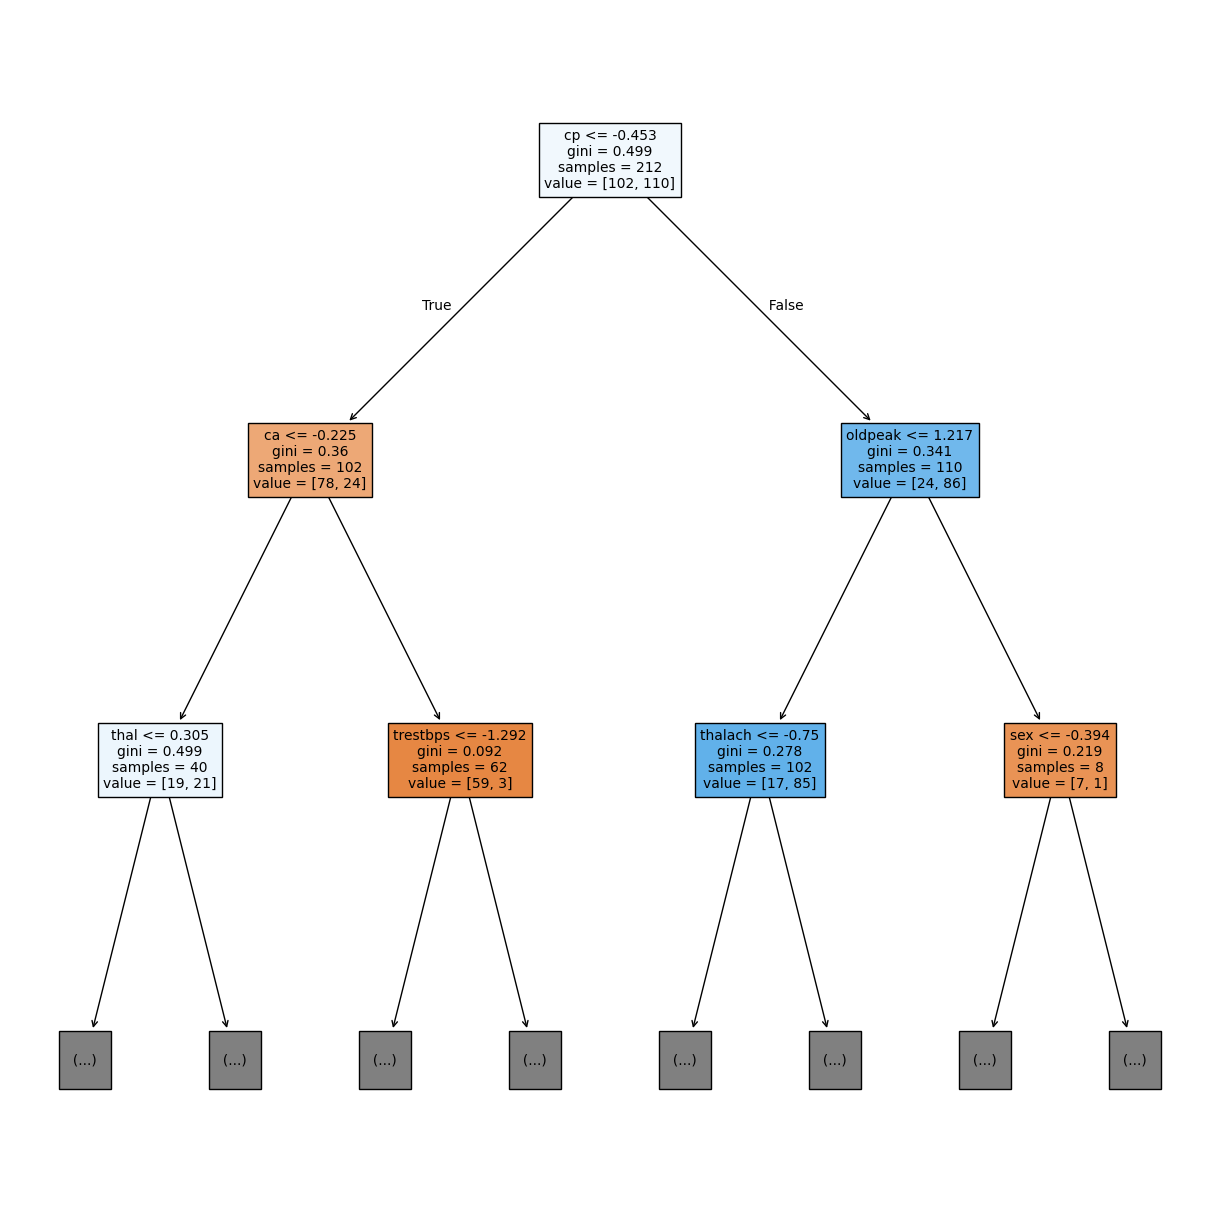

In [40]:
fig = plt.figure(figsize=(12,12)) # Ajusté tamaño para ver mejor
ax = fig.add_axes([0,0,1,1])
tree.plot_tree(clf, fontsize=10, ax=ax, max_depth=2, feature_names=X.columns, filled=True)
plt.show()

**PREGUNTA**

6. Del segundo al tercer nivel, ¿mejora la métrica *gini* en todos los casos?

In [ ]:
# Sí, en el sentido global ponderado. El algoritmo CART (que usa sklearn)
# realiza una división solo si esta reduce la impureza total
# (Gini ponderado de los hijos > Gini del padre)

In [ ]:
# Matiz importante: Si miramos nodos individuales, es posible que uno de los
# nodos hijos tenga un Gini más alto que el padre, pero el otro hijo tendrá
# un Gini mucho más bajo (o será puro), haciendo que el promedio ponderado baje.
# Sin embargo, en la mayoría de los casos visuales en niveles altos (profundidad 2 o 3),
# verás que los nodos resultantes tienden a tener colores más intensos (más puros, menor Gini)
# que su nodo origen.

**PREGUNTA** Si lo que nos interesa es acertar bien los que tienen problemas de corazón, aunque detectemos algunos que no lo sean. (De esta manera evitamos que aquellos que si que tienen problemas no los perdamos)

7. ¿Qué métrica debemos analizar?

In [ ]:
# Debemos analizar el Recall (también llamado Sensibilidad o Tasa de Verdaderos Positivos)

$$Recall = \frac{TP}{TP + FN}$$

In [ ]:
# TP: Verdaderos Positivos (Enfermos detectados correctamente).
# FN: Falsos Negativos (Enfermos que el modelo dijo que estaban sanos).

In [ ]:
# Se busca minimizar los FN (no mandar a casa a alguien enfermo), lo que maximiza el Recall.

In [55]:
from sklearn.metrics import recall_score, accuracy_score, confusion_matrix

In [51]:
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'SVM', 'Árbol de Decisión'],
    'Accuracy (Global)': [acc_lr, acc_svm, acc_dt],
    'Recall (Detección Enfermos)': [rec_lr, rec_svm, rec_dt]
})

In [52]:
print(resultados)

                Modelo  Accuracy (Global)  Recall (Detección Enfermos)
0  Regresión Logística           0.813187                     0.840000
1                  SVM           0.802198                     0.880000
2    Árbol de Decisión           0.725275                     0.763636


In [58]:
# Matriz de Confusión del mejor modelo de Recall (SMV)
# Esto nos dice exactamente cuántos enfermos se nos escaparon (Falsos Negativos)
cm = confusion_matrix(y_test_SVM, y_pred_svm)
print("\nMatriz de Confusión (SVM):")
print(f"Sanos detectados (TN): {cm[0][0]} | Falsos Enfermos (FP): {cm[0][1]}")
print(f"Falsos Sanos (FN): {cm[1][0]}   | Enfermos detectados (TP): {cm[1][1]}")

# Se busca minimizar los FN (no mandar a casa a alguien enfermo), lo que maximiza el Recall.


Matriz de Confusión (SVM):
Sanos detectados (TN): 29 | Falsos Enfermos (FP): 12
Falsos Sanos (FN): 6   | Enfermos detectados (TP): 44


¿Encontramos alguna diferencia entre el modelo que era mejor por accuracy que el modelo que es mejor en base a esta definición?


In [ ]:
# Si, el modelo que obtuvo un % mayor de Accuracy es Regresión Logistica -> 0.8131 -> 81,31%
# Aunque en Recall no obtuvo el mejor valor

# El modelo que obtuvo el mejor valor en Recall fue SVM con un 0.88 -> 88%